### DOES A VECTOR AUTOREGRESSION BEAT A UNIVARIATE AUTOREGRESSION AT FORECASTING INFLATION? 
#### THE APPLICATION TO THE EURO AREA AND U.S. DATA

The goal of the project is to find out whether using more information helps forecast
inflation. We compare a univariate **AR** model (inflation from its own past) with a
multivariate **VAR** model (inflation together with unemployment and a short-term interest
rate). The main question is:

> Does the VAR forecast inflation better than the AR?

The notebook is organised in three parts that follow the actual workflow:

- **Part I — Univariate AR analysis:** build and evaluate the AR model on inflation alone.
- **Part II — Multivariate VAR analysis:** build and evaluate the VAR with the two extra series.
- **Part III — Comparison:** put both models (and the best AR we found) side by side.

In [1]:
!pip install statsmodels --quiet

import requests
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

import warnings
warnings.filterwarnings("ignore")

## Data

Three monthly euro-area series, all from the ECB Data Portal (same source and region):

| Variable | Meaning | ECB series |
|---|---|---|
| `inflation` | HICP, annual rate of change (%) | `ICP.M.U2.N.000000.4.ANR` |
| `unemployment` | Unemployment rate (%, seasonally adjusted) | `LFSI.M.U2.S.UNEHRT.TOTAL0.15_74.T` |
| `rate` | 3-month EURIBOR money-market rate (%) | `FM.M.U2.EUR.RT.MM.EURIBOR3MD_.HSTA` |

We use the data up to the end of **2014** to set up the models and forecast from **2015**
onward (so the test period is never used when choosing the models).

In [2]:
def load_ecb(flow, key):
    url = "https://data-api.ecb.europa.eu/service/data/" + flow + "/" + key
    r = requests.get(url, params={"format": "csvdata"}, headers={"Accept": "text/csv"})
    df = pd.read_csv(io.StringIO(r.text))
    s = pd.Series(df["OBS_VALUE"].values, index=pd.to_datetime(df["TIME_PERIOD"]))
    return s.dropna().asfreq("MS")

inflation    = load_ecb("ICP",  "M.U2.N.000000.4.ANR")
unemployment = load_ecb("LFSI", "M.U2.S.UNEHRT.TOTAL0.15_74.T")
rate         = load_ecb("FM",   "M.U2.EUR.RT.MM.EURIBOR3MD_.HSTA")

data = pd.DataFrame({"inflation": inflation, "unemployment": unemployment, "rate": rate})
data = data.dropna().loc["2000-01-01":]

spec_end  = "2014-12-01"      # end of the in-sample (training) period
oos_start = "2015-01-01"      # first month we forecast out-of-sample
train = data.loc[:spec_end]

print("Sample:", data.index.min().date(), "to", data.index.max().date(), "(%d months)" % len(data))
print("Training:", train.index.min().date(), "to", train.index.max().date(), "(%d months)" % len(train))
data.head()

Sample: 2000-01-01 to 2025-12-01 (312 months)
Training: 2000-01-01 to 2014-12-01 (180 months)


,inflation,unemployment,rate
TIME_PERIOD,,,
2000-01-01,1.9,9.0,3.343143
2000-02-01,1.9,8.9,3.536762
2000-03-01,2.0,8.8,3.747044
2000-04-01,1.7,8.7,3.925278
2000-05-01,1.8,8.6,4.362045


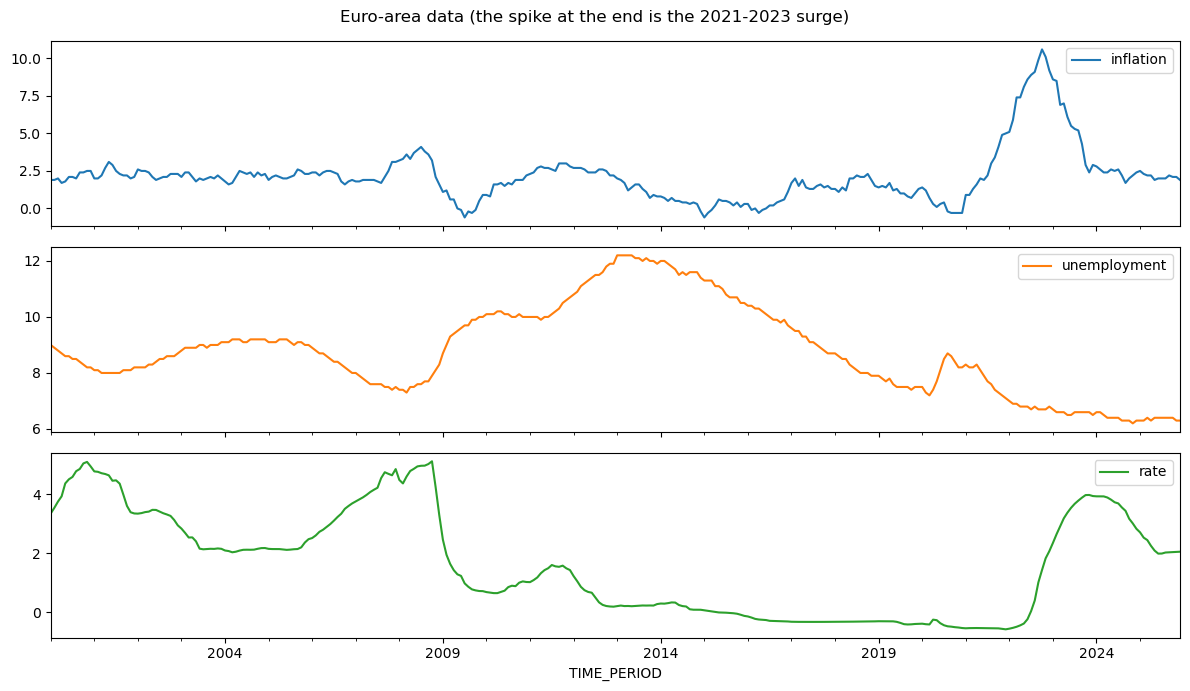

In [3]:
data.plot(subplots=True, figsize=(12, 7), title="Euro-area data (the spike at the end is the 2021-2023 surge)")
plt.tight_layout()
plt.show()

# Part I — Univariate AR analysis

Here we forecast inflation using **only its own past values**. This is the baseline that the
VAR will later have to beat.

## I.1 The inflation series

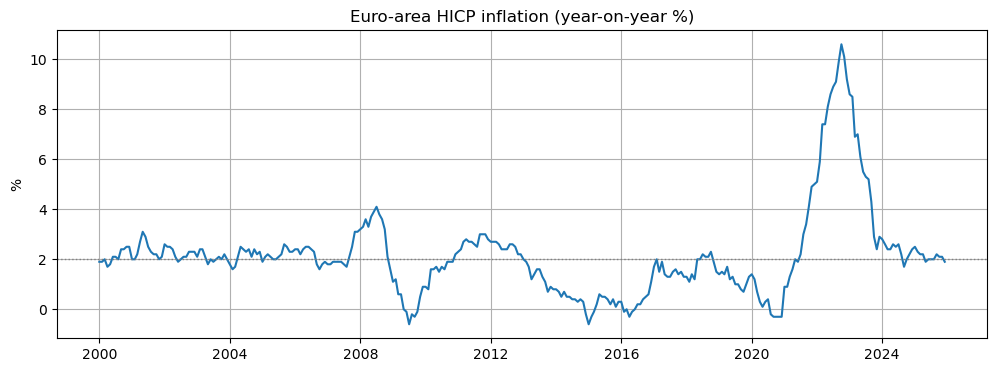

In [4]:
plt.figure(figsize=(12, 4))
plt.plot(data.index, data["inflation"])
plt.axhline(2, color="grey", ls=":", lw=1)
plt.title("Euro-area HICP inflation (year-on-year %)")
plt.ylabel("%"); plt.grid(True)
plt.show()

## I.2 Stationarity (ADF test)

An AR model needs a stationary series. We test inflation with the Augmented Dickey-Fuller
(ADF) test on the training sample. The null hypothesis is a unit root (non-stationary); a
small p-value (< 0.05) lets us reject it.

In [5]:
def adf_test(series, name):
    series = series.dropna()
    pvalue = adfuller(series, regression="c", autolag="AIC")[1]
    decision = "reject unit root" if pvalue < 0.05 else "cannot reject unit root"
    print(f"{name:28s}  ADF p-value = {pvalue:.3f}   ->  {decision}")

adf_test(train["inflation"],        "inflation (level)")
adf_test(train["inflation"].diff(), "inflation (first difference)")

inflation (level)             ADF p-value = 0.448   ->  cannot reject unit root
inflation (first difference)  ADF p-value = 0.000   ->  reject unit root


The ADF test **cannot reject** a unit root for the inflation **level** (p around 0.45). This
is not proof of non-stationarity — it only means we have no evidence against a unit root —
but for modelling we treat the level as non-stationary. The **first difference** is clearly
stationary, so we model inflation in first differences.

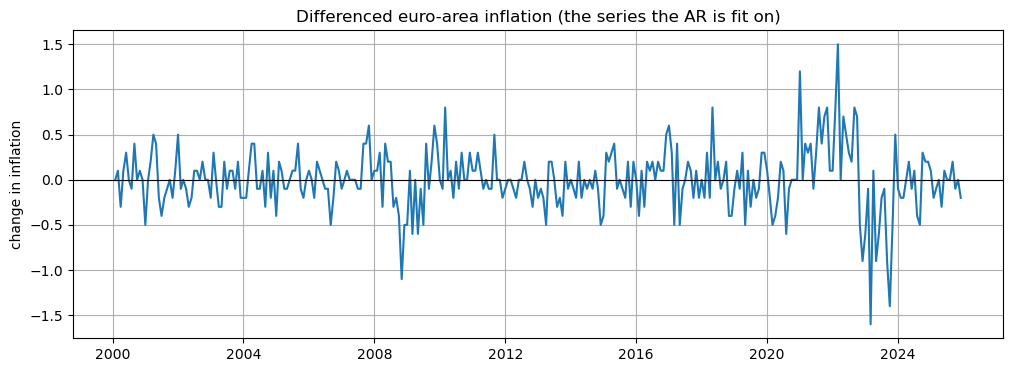

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(data.index, data["inflation"].diff())
plt.axhline(0, color="black", lw=0.8)
plt.title("Differenced euro-area inflation (the series the AR is fit on)")
plt.ylabel("change in inflation"); plt.grid(True)
plt.show()

## I.3 Choosing the lag length

We pick the lag with information criteria on the differenced training data, using `hold_back`
so every lag is estimated on the same sample (otherwise the criteria are not comparable
across lags).

In [7]:
def ar_lag_table(series, max_lag=24):
    rows = []
    for p in range(1, max_lag + 1):
        m = AutoReg(series, lags=p, trend="c", old_names=False, hold_back=max_lag).fit()
        rows.append({"lag": p, "AIC": m.aic, "BIC": m.bic, "HQIC": m.hqic})
    return pd.DataFrame(rows).set_index("lag")

def with_stars(table):
    # mark the minimum of each criterion with a *, like statsmodels' VAR order summary
    mins = {c: table[c].idxmin() for c in table.columns}
    out = pd.DataFrame(index=table.index)
    for c in table.columns:
        out[c] = [f"{v:.2f}" + ("*" if lag == mins[c] else "") for lag, v in table[c].items()]
    return out

ar_table = ar_lag_table(train["inflation"].diff().dropna())
print("AR lag-order selection (* = minimum of each criterion)")
display(with_stars(ar_table))

ar_aic, ar_bic, ar_hqic = int(ar_table.AIC.idxmin()), int(ar_table.BIC.idxmin()), int(ar_table.HQIC.idxmin())
print("AIC ->", ar_aic, "  BIC ->", ar_bic, "  HQIC ->", ar_hqic)
ar_p = ar_aic
print("Chosen AR lag (AIC):", ar_p)

AR lag-order selection (* = minimum of each criterion)


,AIC,BIC,HQIC
lag,,,
1,14.03,23.16,17.74
2,9.20,21.38*,14.15
3,10.11,25.32,16.29
4,7.34,25.60,14.76
5,8.73,30.03,17.38
6,10.18,34.53,20.07
7,9.26,36.65,20.38
8,3.31,33.75,15.67
9,3.25,36.72,16.85


AIC -> 12   BIC -> 2   HQIC -> 12
Chosen AR lag (AIC): 12


AIC and HQIC pick a **12-lag** model. Lag 12 on monthly data captures the yearly (seasonal)
pattern in inflation; a univariate AR can afford 12 coefficients easily. We use **AR(12)**.

## I.4 Fit and residual diagnostics

A well-specified AR should leave **white-noise residuals** (no leftover autocorrelation). We
check this with the residual ACF and the Ljung-Box test.

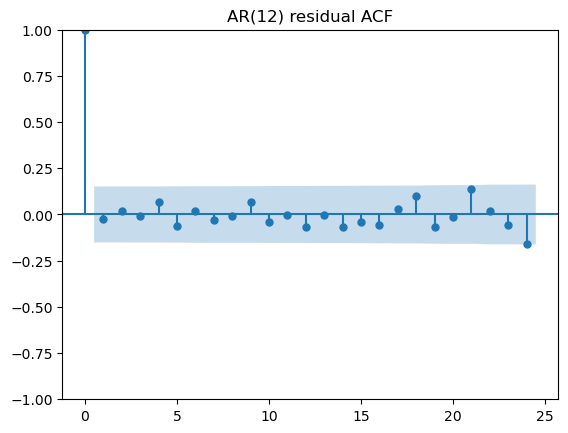

      lb_stat  lb_pvalue
18   7.751678   0.256866
24  17.848415   0.120371


In [8]:
ar_model = AutoReg(train["inflation"].diff().dropna(), lags=ar_p, trend="c", old_names=False).fit()

plot_acf(ar_model.resid, lags=24)
plt.title(f"AR({ar_p}) residual ACF")
plt.show()

# Ljung-Box on the residuals, with model_df = ar_p so the chi-square df accounts for the
# 12 fitted lags (we test at lags beyond ar_p, where the test is meaningful)
print(acorr_ljungbox(ar_model.resid, lags=[18, 24], model_df=ar_p, return_df=True))

The residual ACF stays inside the band, and the Ljung-Box test (adjusted for the 12 fitted
lags via `model_df`) does not reject at lags 18 or 24. So **no strong residual autocorrelation
remains** — the AR(12) is an adequate fit.

## I.5 Forecasting: AR vs no-change

We forecast inflation out-of-sample with an **expanding window** (re-estimated at every step,
no look-ahead) and compare the AR against the naive **no-change (random walk)** benchmark.
Because we model differences, we rebuild the inflation level by adding the forecast change(s)
to the last observed value.

In [9]:
# --- forecasting building blocks (used in all three parts) ---
def forecast_ar(history, p, h):
    d = history["inflation"].diff().dropna()
    ch = AutoReg(d, lags=p, trend="c", old_names=False).fit().forecast(steps=h).to_numpy()
    return history["inflation"].iloc[-1] + np.cumsum(ch)[-1]

def forecast_rw(history, h):
    return history["inflation"].iloc[-1]

def backtest(h, models):
    # models: dict name -> function(history, h)
    rows = []
    for date in data.index[data.index >= pd.Timestamp(oos_start)]:
        history = data.loc[:date - pd.DateOffset(months=h)]
        if len(history) < 60:
            continue
        row = {"date": date, "actual": data["inflation"].loc[date]}
        for name, fn in models.items():
            row[name] = fn(history, h)
        rows.append(row)
    return pd.DataFrame(rows).set_index("date")

def accuracy(fc, model):
    e = fc["actual"] - fc[model]
    return np.sqrt(np.mean(e**2)), np.mean(np.abs(e))

def diebold_mariano(error1, error2, nlags=6):
    # equal-accuracy test with a Newey-West (HAC) variance; small p = significant difference
    d = error1**2 - error2**2
    n = len(d); dc = d - d.mean()
    var = np.sum(dc**2) / n
    for k in range(1, nlags + 1):
        var += 2 * (1 - k / (nlags + 1)) * np.sum(dc[k:] * dc[:-k]) / n
    stat = d.mean() / np.sqrt(var / n)
    return 2 * (1 - stats.norm.cdf(abs(stat)))

ar_fc = backtest(1, {"AR12": lambda H, h: forecast_ar(H, ar_p, h),
                     "RW":   forecast_rw})
print("One-step-ahead accuracy (2015 onward)")
for m in ["AR12", "RW"]:
    rmse, mae = accuracy(ar_fc, m)
    print(f"  {m:5s}: RMSE = {rmse:.3f}   MAE = {mae:.3f}")
print("\nDiebold-Mariano, AR(12) vs RW: p-value =",
      round(diebold_mariano((ar_fc.actual-ar_fc.AR12).values, (ar_fc.actual-ar_fc.RW).values), 3))

One-step-ahead accuracy (2015 onward)
  AR12 : RMSE = 0.369   MAE = 0.271
  RW   : RMSE = 0.425   MAE = 0.299

Diebold-Mariano, AR(12) vs RW: p-value = 0.067


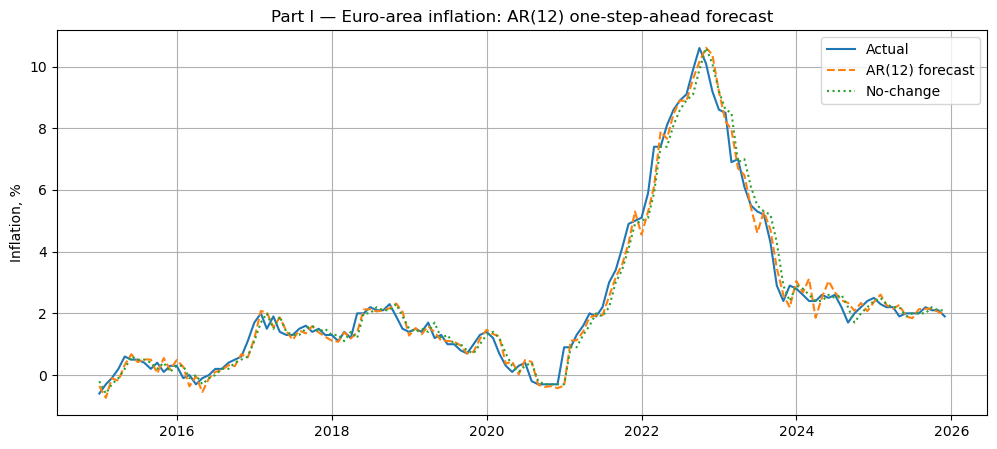

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(ar_fc.index, ar_fc["actual"], label="Actual", linewidth=1.5)
plt.plot(ar_fc.index, ar_fc["AR12"], "--", label=f"AR({ar_p}) forecast")
plt.plot(ar_fc.index, ar_fc["RW"], ":", label="No-change")
plt.title(f"Part I — Euro-area inflation: AR({ar_p}) one-step-ahead forecast")
plt.ylabel("Inflation, %"); plt.legend(); plt.grid(True)
plt.show()

In [11]:
print("AR vs RW, RMSE by horizon")
print("h    AR(12)  RW")
for h in [1, 3, 6, 12]:
    fc = backtest(h, {"AR12": lambda H, hh: forecast_ar(H, ar_p, hh), "RW": forecast_rw})
    print(f"{h:<3}  {accuracy(fc,'AR12')[0]:.3f}   {accuracy(fc,'RW')[0]:.3f}")

AR vs RW, RMSE by horizon
h    AR(12)  RW


1    0.369   0.425


3    0.820   0.932


6    1.445   1.595


12   2.876   2.728


## I.6 Part I conclusion

The **AR(12)** is a well-specified univariate model (white residuals). It beats the no-change
benchmark on RMSE at short and medium horizons, though the gap is only **marginally
significant** (Diebold-Mariano p around 0.07). This is the baseline the VAR has to beat.

# Part II — Multivariate VAR analysis

Now we add **unemployment** and the **interest rate** and build a three-variable VAR, to see
whether this extra information improves the inflation forecast.

## II.1 Stationarity of all three series

A VAR needs every component stationary. We run the ADF test on each series (training sample).

In [12]:
print("LEVELS")
for col in data.columns:
    adf_test(train[col], col)
print("\nFIRST DIFFERENCES")
for col in data.columns:
    adf_test(train[col].diff(), col + " (diff)")

LEVELS
inflation                     ADF p-value = 0.448   ->  cannot reject unit root
unemployment                  ADF p-value = 0.502   ->  cannot reject unit root
rate                          ADF p-value = 0.495   ->  cannot reject unit root

FIRST DIFFERENCES
inflation (diff)              ADF p-value = 0.000   ->  reject unit root
unemployment (diff)           ADF p-value = 0.024   ->  reject unit root
rate (diff)                   ADF p-value = 0.004   ->  reject unit root


All three series are non-stationary in levels and stationary in first differences, so we
model the VAR in **first differences** — the same transformation the AR uses for inflation.

In [13]:
data_diff = data.diff().dropna()

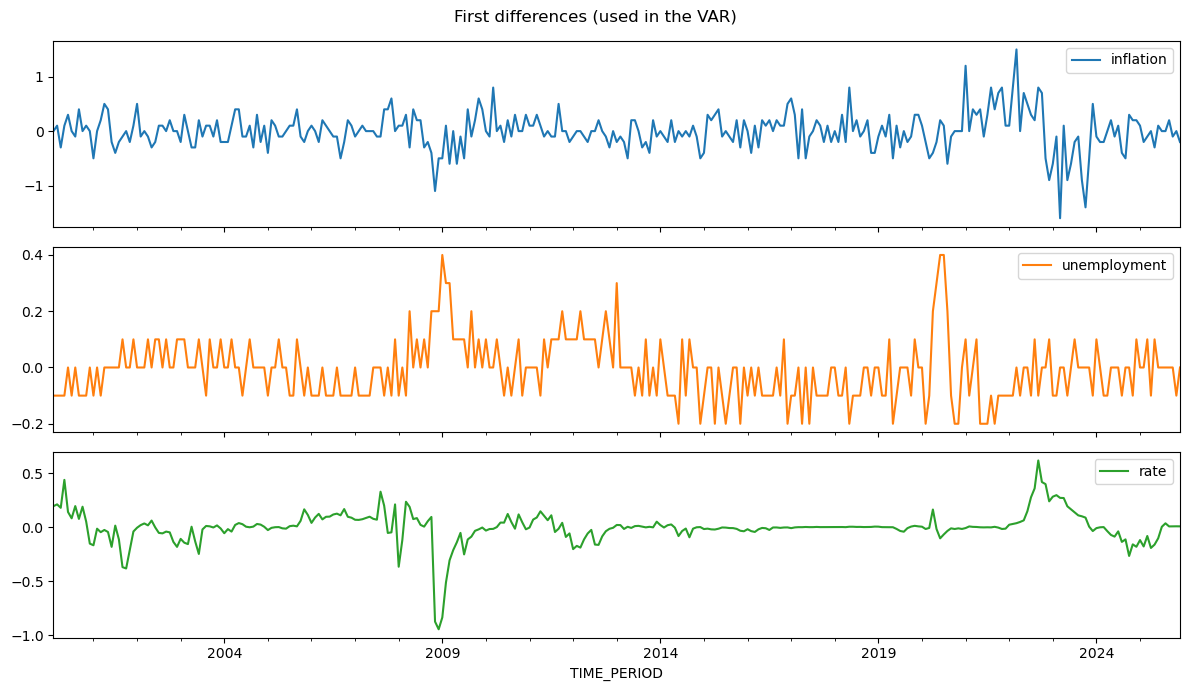

In [14]:
data_diff.plot(subplots=True, figsize=(12, 7), title="First differences (used in the VAR)")
plt.tight_layout()
plt.show()

## II.2 Cointegration check (Johansen test)

If the non-stationary series share a long-run relationship (cointegration), a VAR in
differences would be wrong and we would need a VECM instead. We test this with the Johansen
trace test (null hypothesis: cointegration rank at most r).

In [15]:
johansen = coint_johansen(train.values, det_order=0, k_ar_diff=2)
print("Johansen trace test")
print("rank r | trace stat | 5% critical | reject H0?")
rank = 0
for r in range(len(johansen.lr1)):
    stat, crit = johansen.lr1[r], johansen.cvt[r, 1]
    reject = stat > crit
    rank += int(reject)
    print(f"   {r}   |   {stat:7.2f}  |   {crit:7.2f}   |   {reject}")
print("\nCointegration rank:", rank)

Johansen trace test
rank r | trace stat | 5% critical | reject H0?
   0   |     30.76  |     29.80   |   True
   1   |     11.54  |     15.49   |   False
   2   |      2.37  |      3.84   |   False

Cointegration rank: 1


The trace statistic at rank 0 is only **just above** the 5% critical value, so the test
marginally points to one cointegrating relationship — a borderline rejection that is
sample-dependent. A rigorous treatment of strong cointegration would use a VECM; since the
evidence is weak and we are comparing forecasts (both models in first differences), we keep
the simple **VAR in differences** and note the VECM only as a possible refinement.

## II.3 Choosing the lag length

A VAR with K=3 variables and p lags has 9p slope coefficients, so it gets expensive fast and
we prefer a small model.

In [16]:
selection = VAR(data_diff.loc[:spec_end]).select_order(maxlags=24)
print(selection.summary())                       # full table, * marks each criterion's minimum
print("\nAIC ->", selection.aic, "  BIC ->", selection.bic, "  HQIC ->", selection.hqic)
var_p = selection.hqic    # BIC -> 1, AIC/HQIC -> 2; use the parsimonious HQIC choice
print("Chosen VAR lag (HQIC):", var_p)

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -11.37      -11.31   1.156e-05      -11.34
1       -12.20     -11.96*   5.048e-06      -12.10
2      -12.31*      -11.90  4.492e-06*     -12.15*
3       -12.24      -11.65   4.833e-06      -12.00
4       -12.23      -11.46   4.889e-06      -11.92
5       -12.15      -11.21   5.276e-06      -11.77
6       -12.10      -10.98   5.591e-06      -11.64
7       -12.08      -10.79   5.679e-06      -11.56
8       -12.07      -10.60   5.787e-06      -11.47
9       -12.01      -10.36   6.187e-06      -11.34
10      -12.03      -10.20   6.081e-06      -11.29
11      -12.00      -9.998   6.276e-06      -11.19
12      -12.06      -9.885   5.927e-06      -11.18
13      -12.00      -9.644   6.370e-06      -11.04
14      -12.00      -9.471   6.400e-06      -10.98
15      -12.13      -9.424   5.679e-06      -11.03
16      -12.20      -9.318   5.

The criteria point to a small VAR (BIC picks 1, AIC and HQIC pick 2). We use **p=2**. A
VAR(2) already has 21 coefficients; going to 12 lags like the AR would cost over 100
coefficients, which is the over-parameterisation we want to avoid.

## II.4 Fit and diagnostics

We check the VAR's **stability**, **residual whiteness** (multivariate Ljung-Box / Hosking),
and **Granger causality** (do the extra series help predict inflation?).

In [17]:
var_model = VAR(data_diff.loc[:spec_end]).fit(var_p)
print("Stable model:", var_model.is_stable())
print("Residual whiteness (Hosking) p-value:",
      round(var_model.test_whiteness(nlags=12, adjusted=True).pvalue, 3))
gc = var_model.test_causality("inflation", ["unemployment", "rate"], kind="f")
print("Granger causality (unemployment, rate -> inflation): p-value =", round(gc.pvalue, 3))

Stable model: True
Residual whiteness (Hosking) p-value: 0.013
Granger causality (unemployment, rate -> inflation): p-value = 0.456


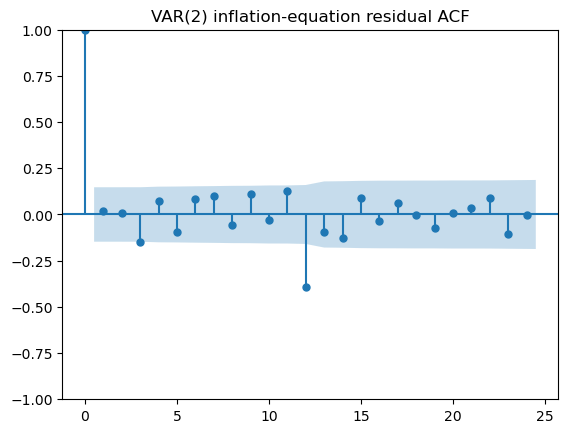

In [18]:
plot_acf(var_model.resid["inflation"], lags=24)
plt.title(f"VAR({var_p}) inflation-equation residual ACF")
plt.show()

Two things stand out:

- **Granger causality is not significant** (p around 0.46): unemployment and the rate do not
  help predict inflation once we know its own past. This already hints the VAR will not win.
- The **residual whiteness test is rejected** (p around 0.01) and the residual ACF still
  spikes near lag 12: the small VAR(2) cannot capture the yearly seasonal pattern. Whitening
  it would need about 12 lags (over 100 coefficients), which the VAR cannot afford — but the
  univariate AR(12) can, which is exactly why AR(12) ends up being the best model.

## II.5 Forecasting: VAR vs matched AR vs no-change

We compare the VAR against a univariate AR with the **same lag** (the VAR with the other
variables removed, so the two are directly comparable / nested) and the no-change benchmark.

*Note:* since the AR and no-change forecasts are nested in the VAR, the Diebold-Mariano test
is not perfectly suited to these comparisons (a Clark-West test would be more exact), but the
models are so close here that it does not change the picture.

In [19]:
def forecast_var(history, p, h):
    d = history.diff().dropna()
    fc = VAR(d).fit(p).forecast(d.values[-p:], steps=h)
    return history["inflation"].iloc[-1] + np.cumsum(fc[:, 0])[-1]

var_fc = backtest(1, {"VAR": lambda H, h: forecast_var(H, var_p, h),
                      "AR":  lambda H, h: forecast_ar(H, var_p, h),
                      "RW":  forecast_rw})
print("One-step-ahead accuracy (2015 onward)")
for m in ["VAR", "AR", "RW"]:
    rmse, mae = accuracy(var_fc, m)
    print(f"  {m:5s}: RMSE = {rmse:.3f}   MAE = {mae:.3f}")
print("\nDiebold-Mariano p-values:")
print("  VAR vs AR(2):", round(diebold_mariano((var_fc.actual-var_fc.VAR).values, (var_fc.actual-var_fc.AR).values), 3))
print("  VAR vs RW   :", round(diebold_mariano((var_fc.actual-var_fc.VAR).values, (var_fc.actual-var_fc.RW).values), 3))

One-step-ahead accuracy (2015 onward)
  VAR  : RMSE = 0.399   MAE = 0.286
  AR   : RMSE = 0.402   MAE = 0.288
  RW   : RMSE = 0.425   MAE = 0.299

Diebold-Mariano p-values:
  VAR vs AR(2): 0.42
  VAR vs RW   : 0.075


In [20]:
print("VAR vs AR vs RW, RMSE by horizon")
print("h    VAR(2)  AR(2)   RW")
for h in [1, 3, 6, 12]:
    fc = backtest(h, {"VAR": lambda H, hh: forecast_var(H, var_p, hh),
                      "AR":  lambda H, hh: forecast_ar(H, var_p, hh),
                      "RW":  forecast_rw})
    print(f"{h:<3}  {accuracy(fc,'VAR')[0]:.3f}   {accuracy(fc,'AR')[0]:.3f}   {accuracy(fc,'RW')[0]:.3f}")

VAR vs AR vs RW, RMSE by horizon
h    VAR(2)  AR(2)   RW


1    0.399   0.402   0.425


3    0.842   0.862   0.932


6    1.479   1.505   1.595


12   2.728   2.729   2.728


## II.6 Robustness: does the lag choice matter?

BIC suggested 1 lag and AIC/HQIC suggested 2, so it is worth checking whether the verdict
depends on this. The table below repeats the out-of-sample comparison with **p = 1** and
**p = 2** for both the VAR and the matched AR.

In [21]:
print("Out-of-sample RMSE with p=1 vs p=2")
print("h    VAR(1)  VAR(2)   AR(1)   AR(2)")
for h in [1, 3, 6, 12]:
    fc = backtest(h, {"VAR1": lambda H, hh: forecast_var(H, 1, hh),
                      "VAR2": lambda H, hh: forecast_var(H, 2, hh),
                      "AR1":  lambda H, hh: forecast_ar(H, 1, hh),
                      "AR2":  lambda H, hh: forecast_ar(H, 2, hh)})
    print(f"{h:<3}  {accuracy(fc,'VAR1')[0]:.3f}   {accuracy(fc,'VAR2')[0]:.3f}    "
          f"{accuracy(fc,'AR1')[0]:.3f}   {accuracy(fc,'AR2')[0]:.3f}")

Out-of-sample RMSE with p=1 vs p=2
h    VAR(1)  VAR(2)   AR(1)   AR(2)


1    0.410   0.399    0.408   0.402


3    0.914   0.842    0.904   0.862


6    1.610   1.479    1.575   1.505


12   2.828   2.728    2.768   2.729


The numbers are very close at both lag lengths: p=2 is a little better than p=1 overall, and
at each horizon the VAR and the matched AR are within a few percent of each other (the tiny
gap even changes sign between p=1 and p=2, and it is not statistically significant — see the
Diebold-Mariano test in II.5). So the conclusion — the VAR does not beat the AR — does not
depend on whether we use one or two lags.

## II.7 Part II conclusion

The VAR(2) is **about tied** with the matched AR(2) at every horizon (Diebold-Mariano finds
no significant difference), and only marginally beats no-change. Adding unemployment and the
interest rate does **not** improve the inflation forecast — consistent with the insignificant
Granger test.

# Part III — AR vs VAR: putting it together

Finally we compare all the models on the same out-of-sample test: the **VAR(2)**, the matched
**AR(2)**, the best univariate **AR(12)** from Part I, and the **no-change** benchmark.

In [22]:
print("RMSE by forecast horizon (lower is better)")
print("h    VAR(2)  AR(2)   AR(12)  RW")
for h in [1, 3, 6, 12]:
    fc = backtest(h, {"VAR":  lambda H, hh: forecast_var(H, var_p, hh),
                      "AR":   lambda H, hh: forecast_ar(H, var_p, hh),
                      "AR12": lambda H, hh: forecast_ar(H, ar_p, hh),
                      "RW":   forecast_rw})
    print(f"{h:<3}  {accuracy(fc,'VAR')[0]:.3f}   {accuracy(fc,'AR')[0]:.3f}   "
          f"{accuracy(fc,'AR12')[0]:.3f}   {accuracy(fc,'RW')[0]:.3f}")

allfc = backtest(1, {"VAR":  lambda H, h: forecast_var(H, var_p, h),
                     "AR12": lambda H, h: forecast_ar(H, ar_p, h),
                     "RW":   forecast_rw})
print("\nDiebold-Mariano (one-step):")
print("  VAR vs AR(12):", round(diebold_mariano((allfc.actual-allfc.VAR).values, (allfc.actual-allfc.AR12).values), 3))
print("  VAR vs RW:", round(diebold_mariano((allfc.actual-allfc.VAR).values, (allfc.actual-allfc.RW).values), 3))
print("  AR(12) vs RW :", round(diebold_mariano((allfc.actual-allfc.AR12).values, (allfc.actual-allfc.RW).values), 3))

RMSE by forecast horizon (lower is better)
h    VAR(2)  AR(2)   AR(12)  RW


1    0.399   0.402   0.369   0.425


3    0.842   0.862   0.820   0.932


6    1.479   1.505   1.445   1.595


12   2.728   2.729   2.876   2.728



Diebold-Mariano (one-step):
  VAR vs AR(12): 0.163
  VAR vs RW: 0.075
  AR(12) vs RW : 0.067


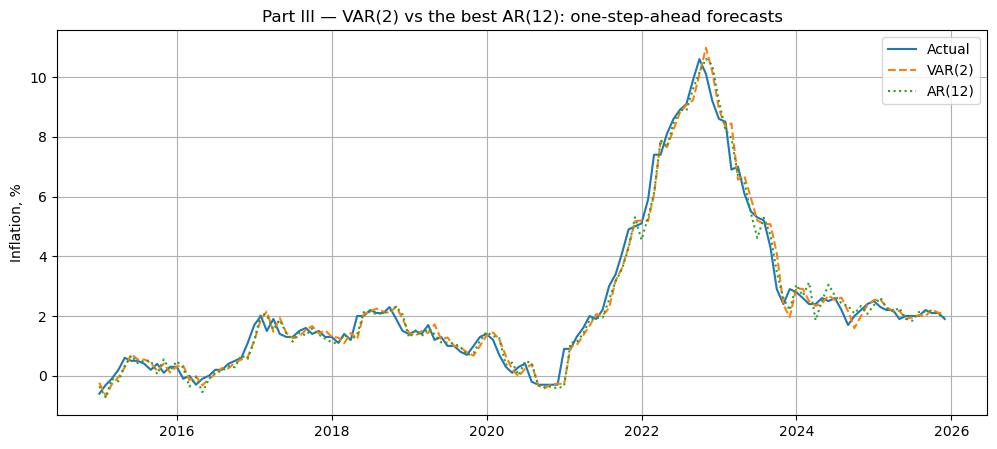

In [23]:
plt.figure(figsize=(12, 5))
plt.plot(allfc.index, allfc["actual"], label="Actual", linewidth=1.5)
plt.plot(allfc.index, allfc["VAR"],  "--", label="VAR(2)")
plt.plot(allfc.index, allfc["AR12"], ":",  label="AR(12)")
plt.title("Part III — VAR(2) vs the best AR(12): one-step-ahead forecasts")
plt.ylabel("Inflation, %"); plt.legend(); plt.grid(True)
plt.show()

## Overall conclusion

For euro-area inflation, the **VAR does not beat the AR**.

- The **Granger test is not significant** (p around 0.46): unemployment and the interest rate
  add no useful information beyond inflation's own past.
- The **VAR(2) and the matched AR(2)** have almost identical RMSE at every horizon, with no
  significant Diebold-Mariano difference.
- The **best univariate AR(12)** is actually the most accurate model at short and medium
  horizons (h = 1, 3, 6), and the VAR does not beat it. At h = 12 the seasonal AR(12) is the
  worst of the three (its many seasonal lags hurt at long range), while the VAR and no-change
  are essentially tied.
- In the **one-step** comparison, the gains over the no-change benchmark are only marginal
  (significant at the 10% level at best); we do not formally test the longer horizons.

So adding more variables does not help here: the simple univariate AR is as good as the VAR,
and the seasonal AR(12) is the best model at the horizons that matter most. This matches the
well-known finding in the inflation-forecasting literature that simple univariate models are
hard to beat.

**Caveats:** the data are revised (not real-time); the cointegration test is borderline at
this split; the VAR(2) residuals are not perfectly white (unmodelled seasonality); and the
2021-2023 surge dominates the long-horizon errors.